In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, StandardScaler
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Load the dataset
df = pd.read_csv('../data/balanced/career_multilabel_dataset_balanced.csv')
df

,age,gender,degree_level,field_of_study,gpa,years_experience,python,java,c_cpp,sql,...,devops,networking,communication,leadership,problem_solving,teamwork,adaptability,recommended_job_1,recommended_job_2,recommended_job_3
0,31,NaN,NaN,Computer Science,2.91,4,1,0,0,1,...,0,0,2,1,4,5,4,Data Engineer,NaN,NaN
1,27,NaN,NaN,Computer Science,2.74,2,0,1,0,0,...,1,1,4,2,3,4,2,Cloud Engineer,NaN,NaN
2,29,Male,PhD,Software Engineering,3.17,1,1,0,1,0,...,0,0,2,1,4,2,2,Machine Learning Engineer,Software Engineer,Data Scientist
3,34,Male,PhD,Computer Science,3.76,4,0,0,1,1,...,1,1,5,4,5,3,4,Software Engineer,DevOps Engineer,AI Researcher
4,26,Male,Master,Cybersecurity,3.98,3,1,0,0,1,...,0,1,2,5,3,4,5,Business Analyst,Cybersecurity Analyst,AI Researcher
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2814,28,Female,Bachelor,Cybersecurity,2.80,1,0,0,0,0,...,1,1,4,4,2,2,1,Cloud Engineer,DevOps Engineer,Cybersecurity Analyst
2815,22,Female,Bachelor,Cybersecurity,3.23,6,0,1,1,1,...,1,1,5,3,1,4,4,Business Analyst,Software Engineer,Cloud Engineer
2816,23,Female,PhD,Cybersecurity,2.64,5,0,1,0,1,...,0,1,1,4,4,3,5,Business Analyst,Software Engineer,Cloud Engineer
2817,34,Male,PhD,Data Science,3.15,5,1,1,1,1,...,0,1,5,2,3,5,5,Machine Learning Engineer,Software Engineer,Cloud Engineer


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2819 entries, 0 to 2818
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2819 non-null   int64  
 1   gender             1846 non-null   str    
 2   degree_level       1846 non-null   str    
 3   field_of_study     2819 non-null   str    
 4   gpa                2819 non-null   float64
 5   years_experience   2819 non-null   int64  
 6   python             2819 non-null   int64  
 7   java               2819 non-null   int64  
 8   c_cpp              2819 non-null   int64  
 9   sql                2819 non-null   int64  
 10  machine_learning   2819 non-null   int64  
 11  data_analysis      2819 non-null   int64  
 12  cloud_computing    2819 non-null   int64  
 13  cybersecurity      2819 non-null   int64  
 14  web_development    2819 non-null   int64  
 15  devops             2819 non-null   int64  
 16  networking         2819 non-null   

In [5]:
df.describe()

,age,gpa,years_experience,python,java,c_cpp,sql,machine_learning,data_analysis,cloud_computing,cybersecurity,web_development,devops,networking,communication,leadership,problem_solving,teamwork,adaptability
count,2819.000000,2819.00000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000,2819.000000
mean,28.174175,3.24663,3.700603,0.619014,0.453352,0.445193,0.606953,0.473217,0.569351,0.542746,0.380631,0.379212,0.482441,0.425328,3.061724,2.795672,3.360057,3.080170,3.160695
std,4.223253,0.41963,2.429803,0.485715,0.497908,0.497075,0.488514,0.499371,0.495255,0.498258,0.485628,0.485277,0.499780,0.494480,1.324184,1.318685,1.368761,1.319435,1.336845
min,18.000000,1.92000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,25.000000,2.90000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,28.000000,3.24000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,4.000000,3.000000,3.000000
75%,32.000000,3.58000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000,5.000000,4.000000,4.000000
max,39.000000,4.00000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [13]:
# Delete gender,age, degree,experience and recommended_job 2,3 columns
df.drop(columns=['gender', 'age', 'degree_level', 'years_experience', 'recommended_job_2', 'recommended_job_3'], inplace=True)

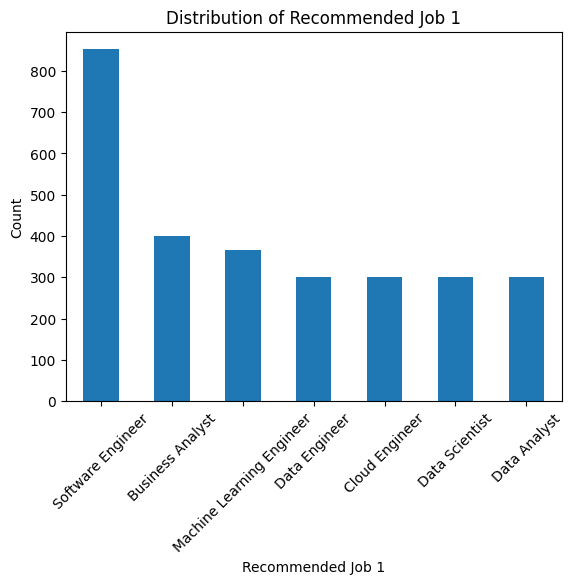

In [ ]:
# Plot the distribution of recommended_job_1
df['recommended_job_1'].value_counts().plot(kind='bar')
plt.title('Distribution of Recommended Job 1')
plt.xlabel('Recommended Job 1')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [10]:
# Encode the target variable
le = LabelEncoder()
df['recommended_job_1'] = le.fit_transform(df['recommended_job_1'])

In [11]:
# Print the mapping of classes to integers
for i, le_class in enumerate(le.classes_):
    print(f"{i}: {le_class}")

0: Business Analyst
1: Cloud Engineer
2: Data Analyst
3: Data Engineer
4: Data Scientist
5: Machine Learning Engineer
6: Software Engineer


Text(0.5, 1.0, 'Correlation Heatmap')

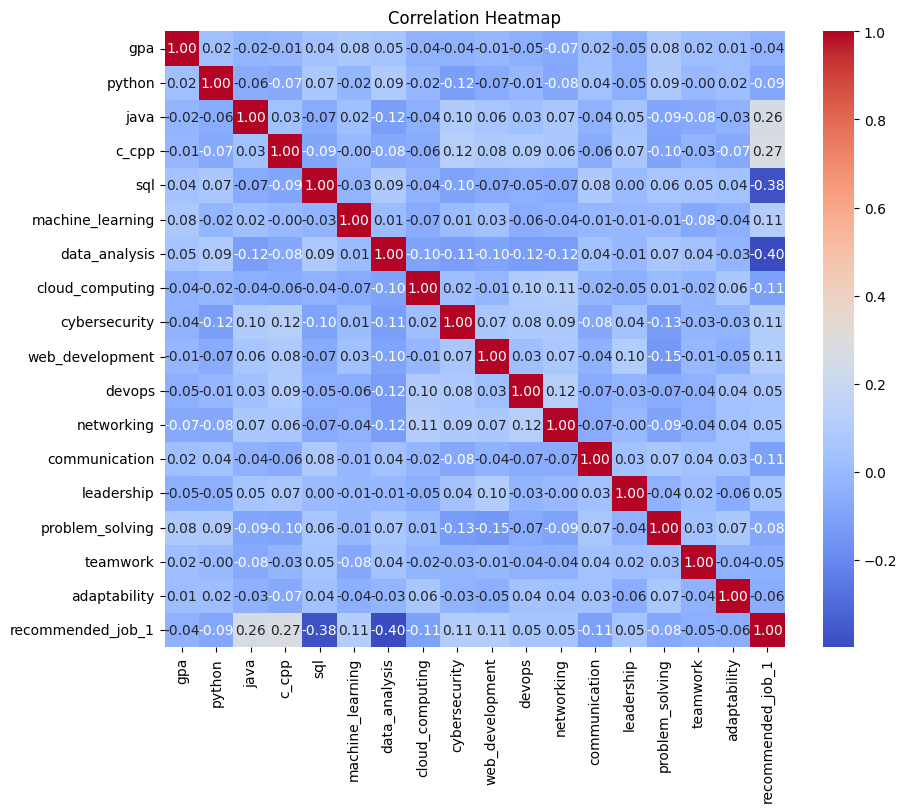

In [14]:
corr = df.corr(numeric_only=True, method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

Moderate correlation with binary skill features

In [14]:
# Prepare features for t-SNE
ss = StandardScaler()
features = df.drop(columns=['recommended_job_1','field_of_study'])
features_scaled = ss.fit_transform(features)

In [15]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(features_scaled)

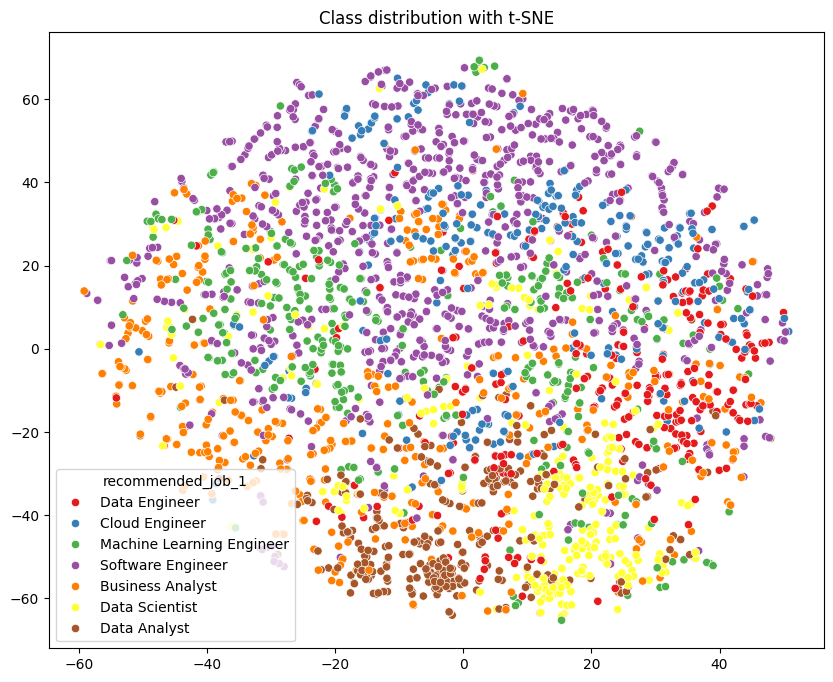

In [16]:
# Visualize the t-SNE results
plt.figure(figsize=(10, 8))
df['recommended_job_1'] = le.inverse_transform(df['recommended_job_1'])
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=df['recommended_job_1'], palette='Set1',)
plt.title('Class distribution with t-SNE')
plt.show()

Strong overlaping, feature engineering is required